In [1]:
import numpy as np

class MultiClassNetwork:
    def __init__(self, units=10, batch_size=32, learning_rate=0.1, l1=0, l2=0):
        self.units = units
        self.batch_size = batch_size
        self.w1 = None
        self.b1 = None
        self.w2 = None
        self.b2 = None
        self.a1 = None
        self.losses = []
        self.val_losses = []
        self.lr = learning_rate
        self.l1 = l1
        self.l2 = l2
    
    def sigmoid(self, z):
        a = 1 / (1 + np.exp(-z))
        return a
    
    def softmax(self, z):
        exp_z = np.exp(z)
        return exp_z / np.sum(exp_z, axis=1).reshape(-1, 1)
    
    def init_weights(self, n_features, n_classes):
        self.w1 = np.random.normal(0, 1, (n_features, self.units))
        self.b1 = np.zeros(self.units)
        self.w2 = np.random.normal(0, 1, (self.units, n_classes))
        self.b2 = np.zeros(n_classes)
        
    def forpass(self, x):
        z1 = np.dot(x, self.w1) + self.b1
        self.a1 = self.sigmoid(z1)
        z2 = np.dot(self.a1, self.w2) + self.b2
        return z2
    
    def backprop(self, x, err):
        m = len(x)
        w2_grad = np.dot(self.a1.T, err) / m
        b2_grad = np.sum(err, axis=0) / m
        
        err_to_hidden = np.dot(err, self.w2.T) * self.a1 * (1 - self.a1)
        
        w1_grad = np.dot(x.T, err_to_hidden) / m
        b1_grad = np.sum(err_to_hidden, axis=0) / m
        return w1_grad, b1_grad, w2_grad, b2_grad
    
    # mini batch generator
    def gen_batch(self, x, y):
        length = len(x)
        bins = length // self.batch_size
        if length % self.batch_size:
            bins += 1
        indexes = np.random.permutation(np.arange(len(x)))
        x = x[indexes]
        y = y[indexes]
        for i in range(bins):
            start = self.batch_size * i
            end = self.batch_size * (i + 1)
            yield x[start:end], y[start:end]
            
    def training(self, x, y):
        m = len(x)
        z = self.forpass(x)
        a = self.softmax(z)
        err = -(y - a)
        w1_grad, b1_grad, w2_grad, b2_grad = self.backprop(x, err)
        w1_grad += (self.l1 * np.sign(self.w1) + self.l2 * self.w1) / m
        w2_grad += (self.l1 * np.sign(self.w2) + self.l2 * self.w2) / m
        self.w1 -= self.lr * w1_grad
        self.b1 -= self.lr * b1_grad
        self.w2 -= self.lr * w2_grad
        self.b2 -= self.lr * b2_grad
        return a
    
    def predict(self, x):
        z = self.forpass(x)
        return np.argmax(z, axis=1)
    
    def score(self, x, y):
        return np.mean(self.predict(x) == np.argmax(y, axis=1))
    
    def reg_loss(self):
        return self.l1 * (np.sum(np.abs(self.w1)) + np.sum(np.abs(self.w2))) + self.l2 / 2 * (np.sum(self.w1**2) + np.sum(self.w2**2))
    
    def update_val_loss(self, x_val, y_val):
        z = self.forpass(x_val)
        a = self.softmax(z)
        a = np.clip(a, 1e-10, 1-1e-10)
        val_loss = np.sum(-y_val * np.log(a))
        self.val_losses.append((val_loss + self.reg_loss()) / len(y_val))
    
    def fit(self, x, y, epochs=100, x_val=None, y_val=None):
        np.random.seed(42)
        self.init_weights(x.shape[1], y.shape[1])
        for i in range(epochs):
            loss = 0
            print('.', end='')
            for x_batch, y_batch in self.gen_batch(x, y):
                a = self.training(x_batch, y_batch)
                a = np.clip(a, 1e-10, 1-1e-10)
                loss += np.sum(-y_batch * np.log(a))
            self.losses.append((loss + self.reg_loss()) / len(x))
            self.update_val_loss(x_val, y_val)

In [2]:
import tensorflow as tf

In [3]:
tf.__version__

'2.21.0'

In [4]:
(x_train_all, y_train_all), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
print(x_train_all.shape, y_train_all.shape)

(60000, 28, 28) (60000,)


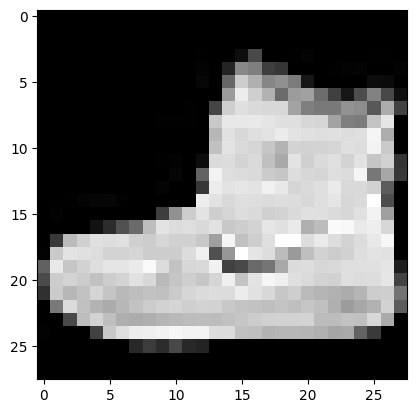

In [5]:
import matplotlib.pyplot as plt
plt.imshow(x_train_all[0], cmap='gray')
plt.show()

In [6]:
print(y_train_all[:10])

[9 0 0 3 0 2 7 2 5 5]


In [7]:
class_names = ['t-shirts', 'pants', 'sweater', 'dress', 'coat', 'sandles', 'shirts', 'sneakers', 'bag', 'ankle-boots']
print(class_names[y_train_all[0]])

ankle-boots


In [8]:
np.bincount(y_train_all)

array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000])

In [9]:
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(x_train_all, y_train_all, stratify=y_train_all, test_size=0.2, random_state=42)
print(np.bincount(y_train))
print(np.bincount(y_val))

[4800 4800 4800 4800 4800 4800 4800 4800 4800 4800]
[1200 1200 1200 1200 1200 1200 1200 1200 1200 1200]


In [10]:
# normalization (not actually but used in practice)
x_train = x_train / 255
x_val = x_val / 255

x_train = x_train.reshape(-1, 784)
x_val = x_val.reshape(-1, 784)
print(x_train.shape, x_val.shape)

(48000, 784) (12000, 784)


In [11]:
tf.keras.utils.to_categorical([0, 1, 3])

array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.]])

In [12]:
y_train_encoded = tf.keras.utils.to_categorical(y_train)
y_val_encoded = tf.keras.utils.to_categorical(y_val)
print(y_train_encoded.shape, y_val_encoded.shape)

(48000, 10) (12000, 10)


In [13]:
print(y_train[0], y_train_encoded[0])

6 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


In [14]:
fc = MultiClassNetwork(units=100, batch_size=256)
fc.fit(x_train, y_train_encoded, x_val=x_val, y_val=y_val_encoded, epochs=40)

........................................

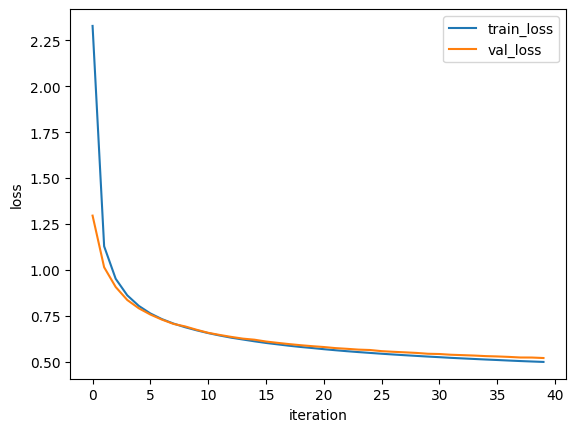

In [15]:
plt.plot(fc.losses)
plt.plot(fc.val_losses)
plt.ylabel('loss')
plt.xlabel('iteration')
plt.legend(['train_loss', 'val_loss'])
plt.show()

In [16]:
fc.score(x_val, y_val_encoded)

np.float64(0.81475)

In [17]:
# w = tf.Variable(tf.zeros(shape=(1)))
w = tf.Variable(tf.zeros(shape=(784, 1)))
b = tf.Variable(tf.zeros(shape=(1)))

optimizer = tf.optimizers.SGD(learning_rate=0.01)

num_epochs = 10
for step in range(num_epochs):
    with tf.GradientTape() as tape:
        # z_net = w * x_train + b
        z_net = tf.matmul(tf.cast(x_train, tf.float32), w) + b
        z_net = tf.reshape(z_net, [-1])
        sqr_errors = tf.square(y_train - z_net)
        mean_cost = tf.reduce_mean(sqr_errors)
    grads = tape.gradient(mean_cost, [w, b])
    optimizer.apply_gradients(zip(grads, [w, b]))
    
    
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Dense(1))
model.compile(optimizer='sgd', loss='mse')
model.fit(x_train, y_train, epochs=10)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 452us/step - loss: nan    
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 440us/step - loss: nan
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 475us/step - loss: nan
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 441us/step - loss: nan
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 441us/step - loss: nan
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 440us/step - loss: nan
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 452us/step - loss: nan
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 440us/step - loss: nan
Epoch 9/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 435us/step - loss: nan
Epoch 10/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 439us/step - loss: nan


In [18]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(100, activation='sigmoid', input_shape=(784,)))
model.add(Dense(10, activation='softmax'))
model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train_encoded, epochs=40, validation_data=(x_val, y_val_encoded))

Epoch 1/40


c:\Users\USER\Desktop\AI\Do_it\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 837us/step - accuracy: 0.6413 - loss: 1.3981 - val_accuracy: 0.7287 - val_loss: 0.9565
Epoch 2/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 765us/step - accuracy: 0.7421 - loss: 0.8361 - val_accuracy: 0.7599 - val_loss: 0.7461
Epoch 3/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 768us/step - accuracy: 0.7634 - loss: 0.7079 - val_accuracy: 0.7763 - val_loss: 0.6625
Epoch 4/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 777us/step - accuracy: 0.7781 - loss: 0.6454 - val_accuracy: 0.7923 - val_loss: 0.6127
Epoch 5/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 761us/step - accuracy: 0.7922 - loss: 0.6044 - val_accuracy: 0.8007 - val_loss: 0.5774
Epoch 6/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 766us/step - accuracy: 0.8017 - loss: 0.5743 - val_accuracy: 0.8074 - val_loss: 0.5520
Epoch 7/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 756us/step - accuracy: 0.8094 - loss: 0.5513 - val_accuracy: 0.8152 - val_loss: 0.5303
Epoch 8/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 762us/step - accuracy: 0.8163 - loss: 0.53

In [19]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


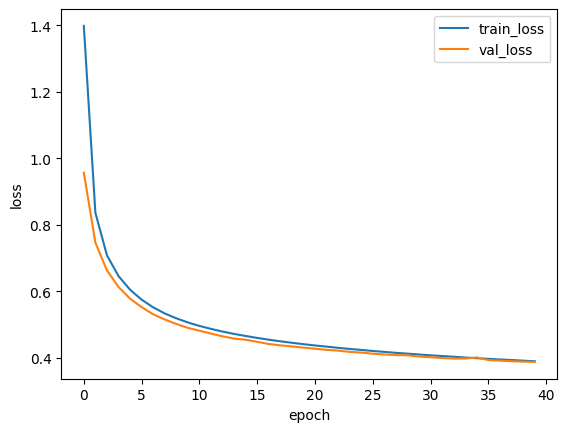

In [20]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train_loss', 'val_loss'])
plt.show()

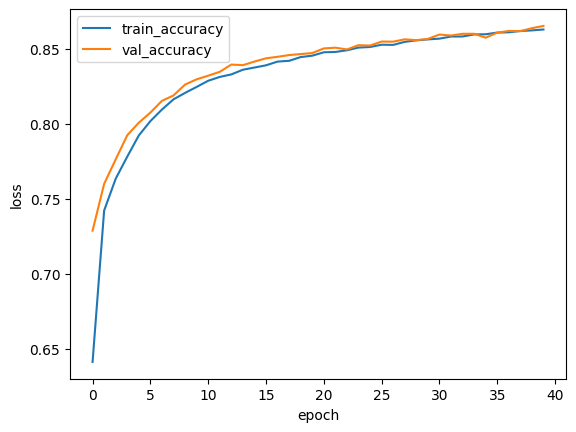

In [21]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train_accuracy', 'val_accuracy'])
plt.show()

In [22]:
loss, accuracy = model.evaluate(x_val, y_val_encoded, verbose=0)
print(accuracy)

0.8651666641235352


In [23]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Convert numpy arrays to PyTorch tensors
x_train_t = torch.tensor(x_train, dtype=torch.float32)
x_val_t = torch.tensor(x_val, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long) # must be Long(int64) for CrossEntropyLoss
y_val_t = torch.tensor(y_val, dtype=torch.long)

print(x_train_t.shape, x_val_t.shape, y_train_t.shape, y_val_t.shape)

torch.Size([48000, 784]) torch.Size([12000, 784]) torch.Size([48000]) torch.Size([12000])


In [25]:
# DataLoader: replaces Keras's batch_size argument in model.fit()
# DataLoader handles batching annd shuffling automatically
train_loader = DataLoader(TensorDataset(x_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(x_val_t, y_val_t), batch_size=256)

In [ ]:
# Define the model
# Same architecture as Keras: 784 → Dense(100, sigmoid) → Dense(10)
# KEY DIFFERENCE: no Softmax at the end!
# nn.CrossEntropyLoss applies log-softmax + NLL loss internally,
# so adding softmax yourself would break the math. In Keras, loss='categorical_crossentropy'
# also handles this, but Keras lets you put softmax in the layer — PyTorch does not want it.

model_pt = nn.Sequential(
	nn.Linear(784, 100),	# equivalent to Dense(100)
    nn.Sigmoid(),			# equivalent to activation = 'sigmoid'
    nn.Linear(100, 10)		# equivalent to Dense(10) - outputs raw logits 
)

# Input Layer          Hidden Layer         Output Layer
# (784 nodes)          (100 nodes)          (10 nodes)
#                      sigmoid              softmax*

#   x₁  ──┐
#   x₂  ──┤                             ┌── ŷ₀  (t-shirt)
#   x₃  ──┤         ┌── h₁  ──┐         ├── ŷ₁  (pants)
#    ⋮    ├────────►├── h₂  ──┼────────►├── ŷ₂  (sweater)
#    ⋮    │         │    ⋮    │         ├── ŷ₃  (dress)
#    ⋮    │         └── h₁₀₀ ──┘        ├── ŷ₄  (coat)
#  x₇₈₃ ──┤                             ├── ŷ₅  (sandals)
#  x₇₈₄ ──┘                             ├── ŷ₆  (shirt)
#                                       ├── ŷ₇  (sneakers)
#                                       ├── ŷ₈  (bag)
#                                       └── ŷ₉  (ankle-boots)

#  28×28 pixels                          argmax(ŷ) = predicted class
#  flattened to 784


In [27]:
# Loss function and optimizer
# CrossEntropyLoss = categorical_crossentropy (but takes integer labels, not one-hot)
# SGD with lr=0.01 matches Keras's default SGD learning rate
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_pt.parameters(), lr=0.01)

In [29]:
# Training loop
# In PyTorch there is no model.fit(). You write the loop yourself.
# This is more verbose but gives you full control over what happens each step.
epochs = 40
pt_history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

for epoch in range(epochs):
    # Training phase
    model_pt.train()	# tells the model it's in training mode (matters for dropout/batchnorm)
    total_loss, correct, total = 0.0, 0, 0
    
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        logits = model_pt(x_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * len(x_batch)	# accummulate total (not mean) loss
        correct += (logits.argmax(dim=1) == y_batch).sum().item()
        total += len(x_batch)
        
    train_loss = total_loss / total
    train_acc = correct / total
    
    # Validation phase
    model_pt.eval()		# switches off training-only behavior
    with torch.no_grad():	# disables gradient tracking — saves memory, speeds up inference
        val_loss, val_correct, val_total = 0.0, 0, 0
        for x_batch, y_batch in val_loader:
            logits = model_pt(x_batch)
            loss = criterion(logits, y_batch)
            val_loss += loss.item() * len(x_batch)
            val_correct += (logits.argmax(dim=1) == y_batch).sum().item()
            val_total += len(x_batch)
            
    val_loss = val_loss / val_total
    val_acc = val_correct / val_total
    
    pt_history['loss'].append(train_loss)
    pt_history['val_loss'].append(val_loss)
    pt_history['accuracy'].append(train_acc)
    pt_history['val_accuracy'].append(val_acc)
    
    print(f'Epoch {epoch+1:2d}/{epochs}  '
          f'loss: {train_loss:.4f}  acc: {train_acc:.4f}  '
          f'val_loss: {val_loss:.4f}  val_acc: {val_acc:.4f}')

Epoch  1/40  loss: 1.0501  acc: 0.7039  val_loss: 0.8978  val_acc: 0.7285
Epoch  2/40  loss: 0.8240  acc: 0.7364  val_loss: 0.7543  val_acc: 0.7511
Epoch  3/40  loss: 0.7239  acc: 0.7526  val_loss: 0.6805  val_acc: 0.7652
Epoch  4/40  loss: 0.6667  acc: 0.7667  val_loss: 0.6338  val_acc: 0.7790
Epoch  5/40  loss: 0.6274  acc: 0.7784  val_loss: 0.5999  val_acc: 0.7877
Epoch  6/40  loss: 0.5974  acc: 0.7907  val_loss: 0.5725  val_acc: 0.7977
Epoch  7/40  loss: 0.5735  acc: 0.7989  val_loss: 0.5508  val_acc: 0.8063
Epoch  8/40  loss: 0.5538  acc: 0.8079  val_loss: 0.5327  val_acc: 0.8124
Epoch  9/40  loss: 0.5372  acc: 0.8134  val_loss: 0.5190  val_acc: 0.8188
Epoch 10/40  loss: 0.5234  acc: 0.8179  val_loss: 0.5054  val_acc: 0.8217
Epoch 11/40  loss: 0.5115  acc: 0.8226  val_loss: 0.4957  val_acc: 0.8257
Epoch 12/40  loss: 0.5011  acc: 0.8263  val_loss: 0.4853  val_acc: 0.8290
Epoch 13/40  loss: 0.4924  acc: 0.8294  val_loss: 0.4761  val_acc: 0.8338
Epoch 14/40  loss: 0.4846  acc: 0.8310

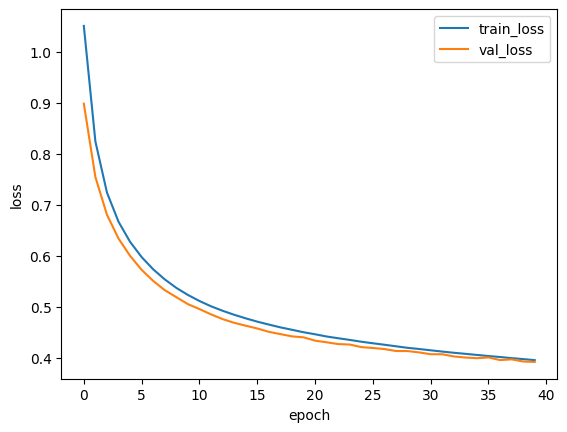

In [30]:
plt.plot(pt_history['loss'])
plt.plot(pt_history['val_loss'])
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train_loss', 'val_loss'])
plt.show()

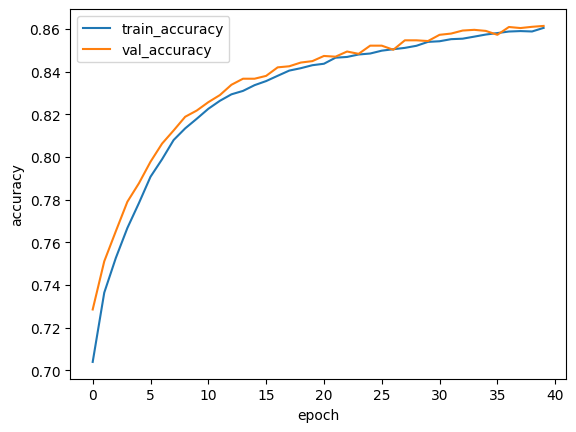

In [31]:
plt.plot(pt_history['accuracy'])
plt.plot(pt_history['val_accuracy'])
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train_accuracy', 'val_accuracy'])
plt.show()

In [32]:
print('Final val accuracy:', round(pt_history['val_accuracy'][-1], 4))

Final val accuracy: 0.8614
